# 09 · Tutorial: the algorithm, block by block

This notebook builds LR-DSR **by hand**, one block at a time, in a few lines
of numpy each, and then shows the one-line package call and the options for
that block. At the end the hand-built loop is checked against the package.

**The idea in one picture** (`docs/algorithm/00_the_idea.png`): windows go
in; two questions alternate ("what is each law?" and "which law made each
window?"); labels and formulas come out.

In [1]:
import sys, pathlib
ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "pyproject.toml").exists())
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from lrdsr import viz
viz.style()
pd.set_option("display.precision", 4)
RES = ROOT / "results"

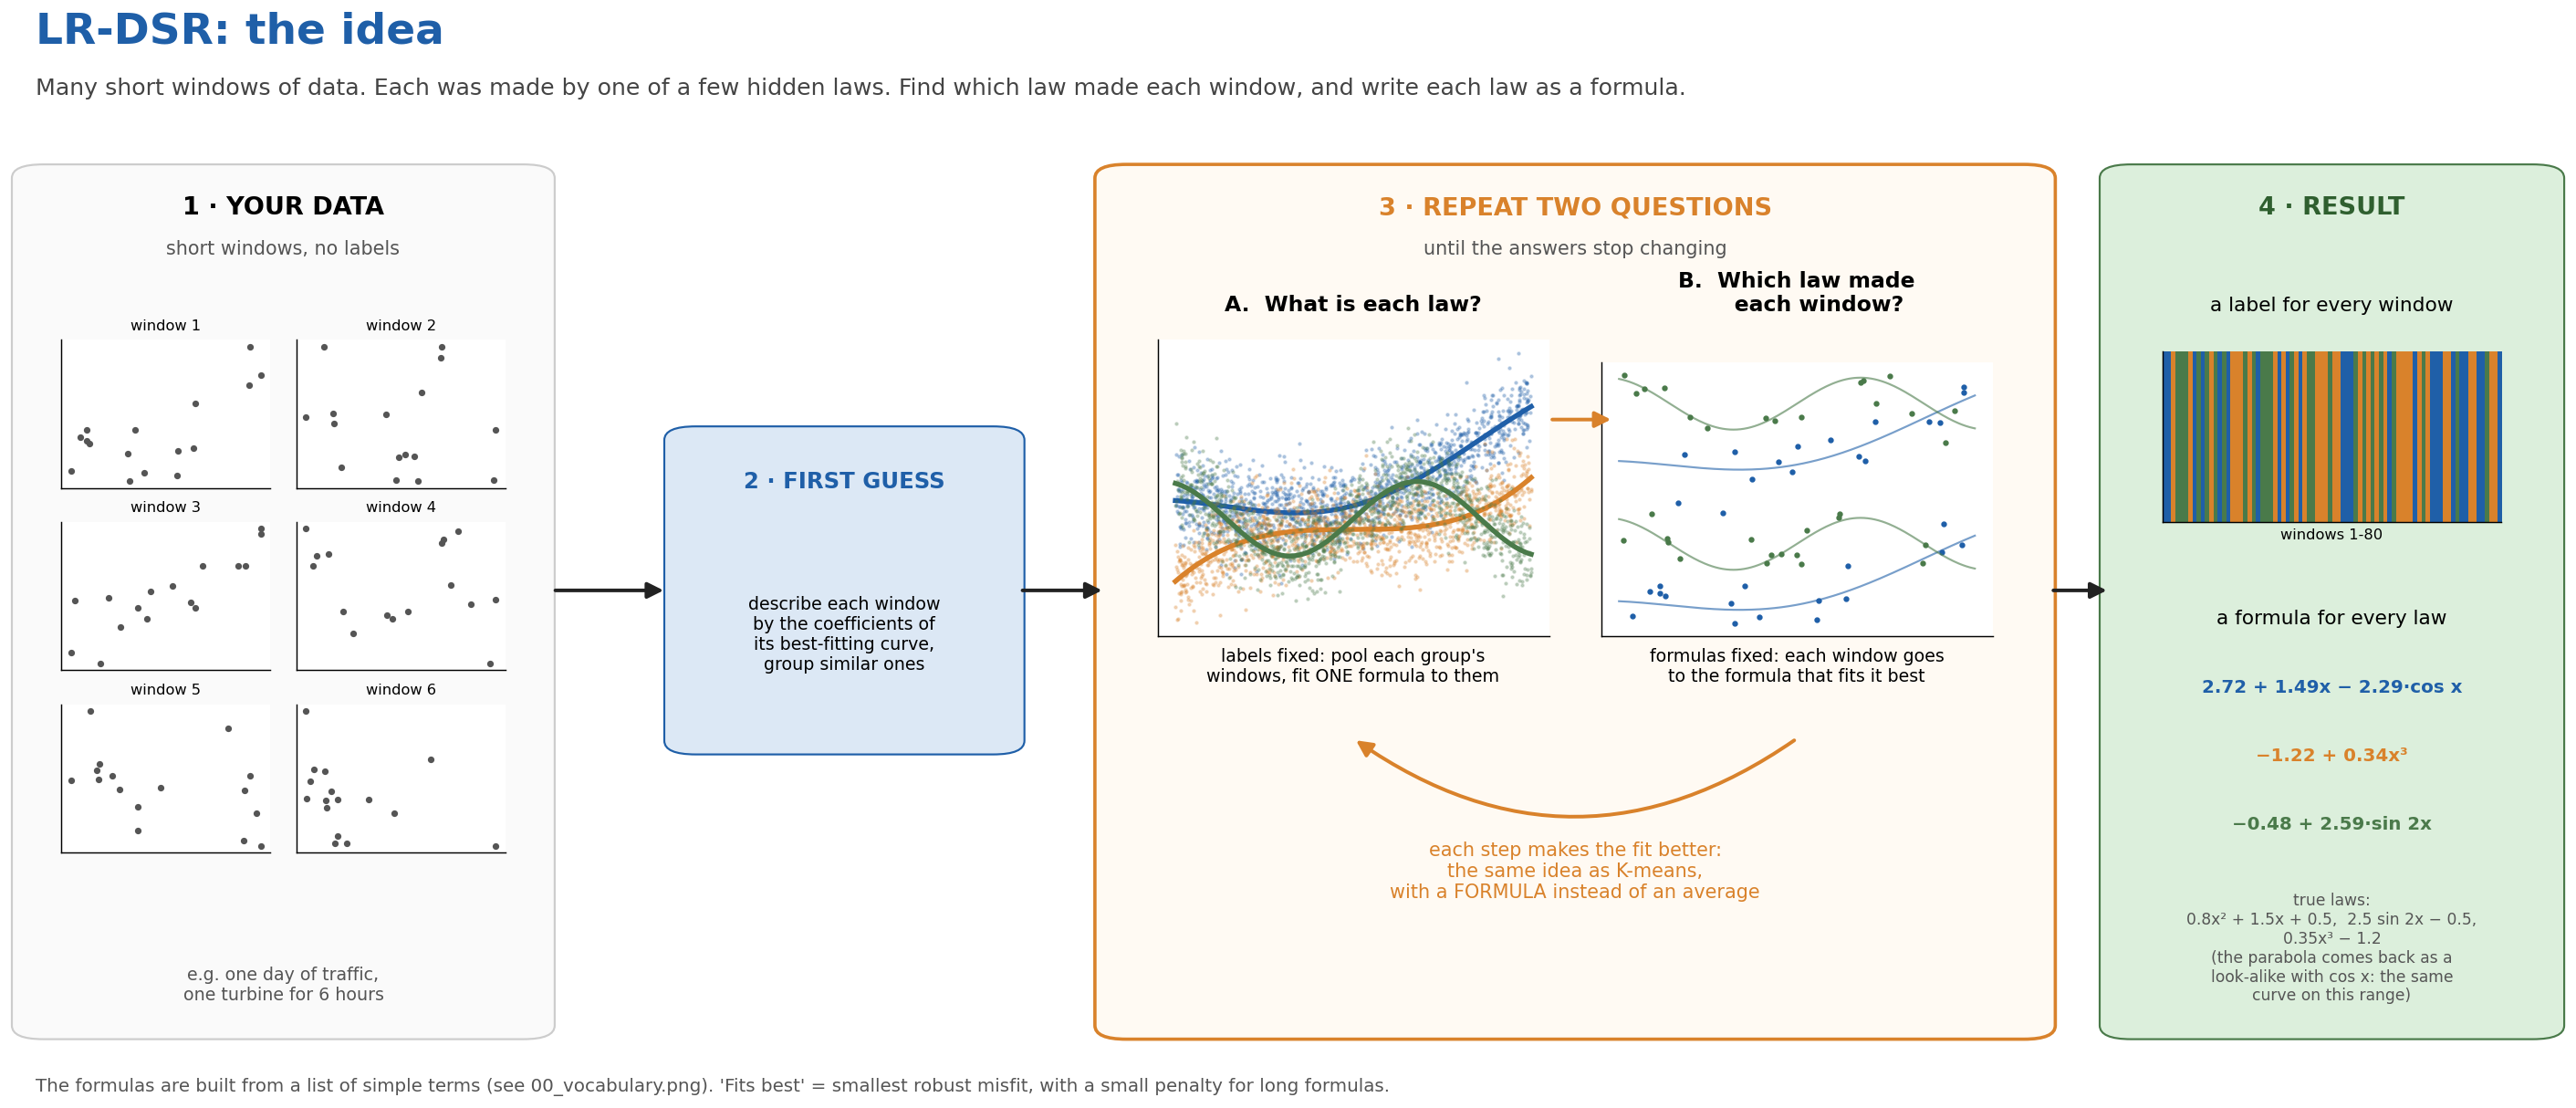

In [2]:
from IPython.display import Image
DOCS = ROOT / "docs" / "algorithm"
Image(filename=str(DOCS / "00_the_idea.png"), width=1100)

---
## The vocabulary: what a law can be built from

A law is never searched among *all* functions. It is a short sum of
**terms**, and the list of allowed terms decides which laws can be written
down exactly. Three levels of vocabulary:

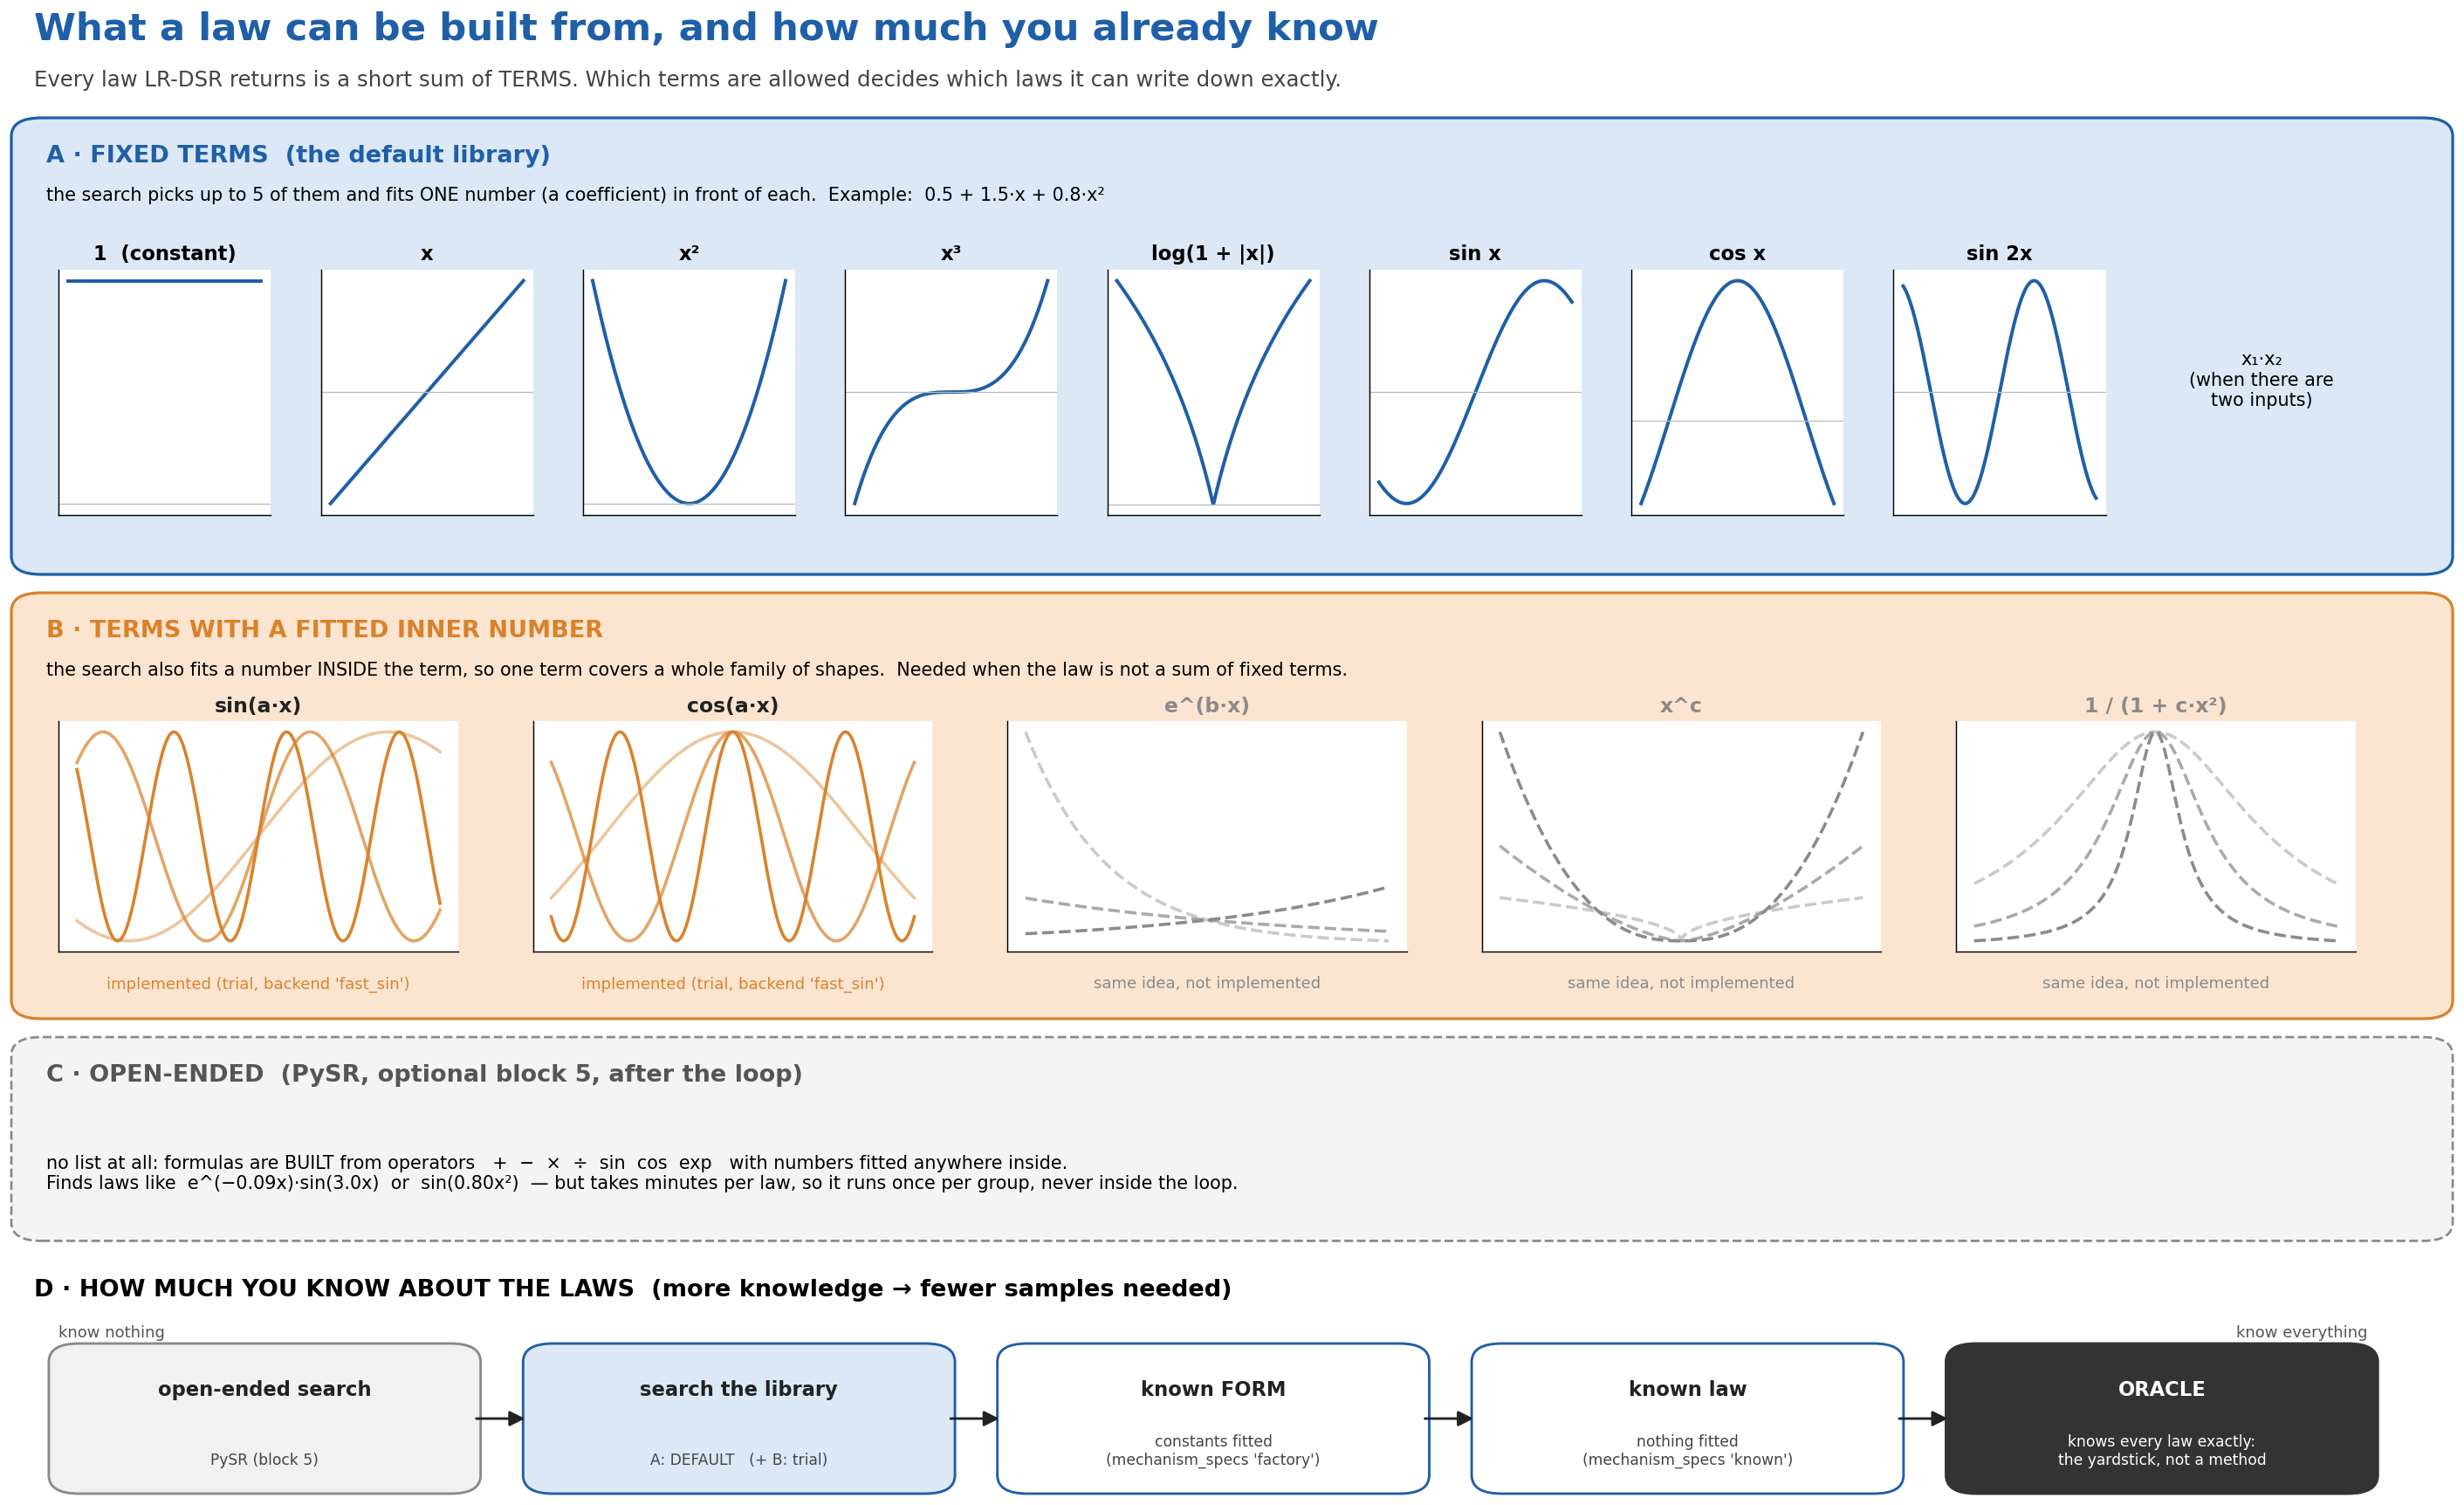

In [3]:
Image(filename=str(DOCS / "00_vocabulary.png"), width=1100)

**A · Fixed terms (the default).** This is the actual list, read from the
code. The search picks up to 5 terms and fits one number in front of each:

the default library: 1, x, (x)^2, (x)^3, log1p(abs(x)), sin(x), cos(x), sin(2*x)
with two inputs x1, x2: the same terms for each, plus the product x1*x2


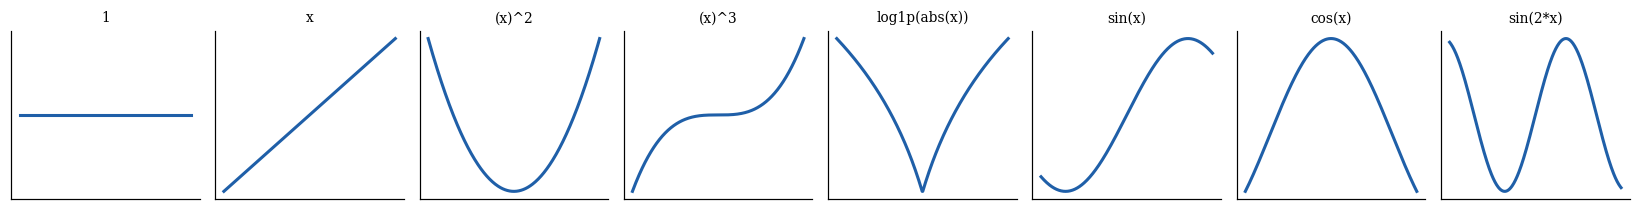

In [4]:
from lrdsr.core.soft import library_terms
xg = np.linspace(-2.2, 2.2, 300)
Phi, names = library_terms(xg[:, None], feature_names=["x"])
print("the default library:", ", ".join(names))
print("with two inputs x1, x2: the same terms for each, plus the product x1*x2")
fig, ax = plt.subplots(1, len(names), figsize=(15, 2.0), sharex=True)
for a, nm, col in zip(ax, names, Phi.T):
    a.plot(xg, col, color=viz.PALETTE[0], lw=2); a.set_title(nm, fontsize=9); a.set(xticks=[], yticks=[])
fig.tight_layout()

**B · Terms with a fitted inner number.** A term like $\sin(a\,x)$ has a
number *inside* it, so one term stands for a whole family of shapes, and the
search fits $a$ as well. `sin(a·x)` and `cos(a·x)` are the only ones
implemented (the `fast_sin` trial). They are **one example** of the idea,
chosen because oscillations were the zoo's failure; $e^{b x}$, $x^c$ or
$1/(1+c x^2)$ would work the same way, but are not implemented.

**C · Open-ended.** PySR builds formulas from operators, with no list at all.
It runs only in the optional block 5, once per group (end of this notebook).

**How much you know about the laws** is the same ladder seen from the other
side. The more you declare, the less the data must tell you:

| you know… | how you say it | what is fitted |
|---|---|---|
| nothing beyond the vocabulary | default (`mechanism_specs=None`) | which terms + their numbers |
| the **form** of a law, e.g. $a\,e^{-b x}$ | `{"mode": "factory", "factory": lambda: ParametricPriorRegressor(form, p0)}` | only $a$, $b$ |
| part of a law | `{"mode": "partial", "prior_function": h}` | the rest, from the library |
| the law exactly | `{"mode": "known", "function": f}` | nothing |
| **every** law exactly | the **oracle** | nothing: it is the yardstick, not a method |

The **oracle** used throughout the project is just the top of this ladder:
it knows every law exactly and labels each window by the smallest residual.
No method can beat it, so every result is measured against it.

---
## The detailed map

Every block, its piece of the objective, what it does to the data, and its
options (`docs/algorithm/00_algorithm_at_a_glance.png`). The rest of this
notebook builds each column by hand.

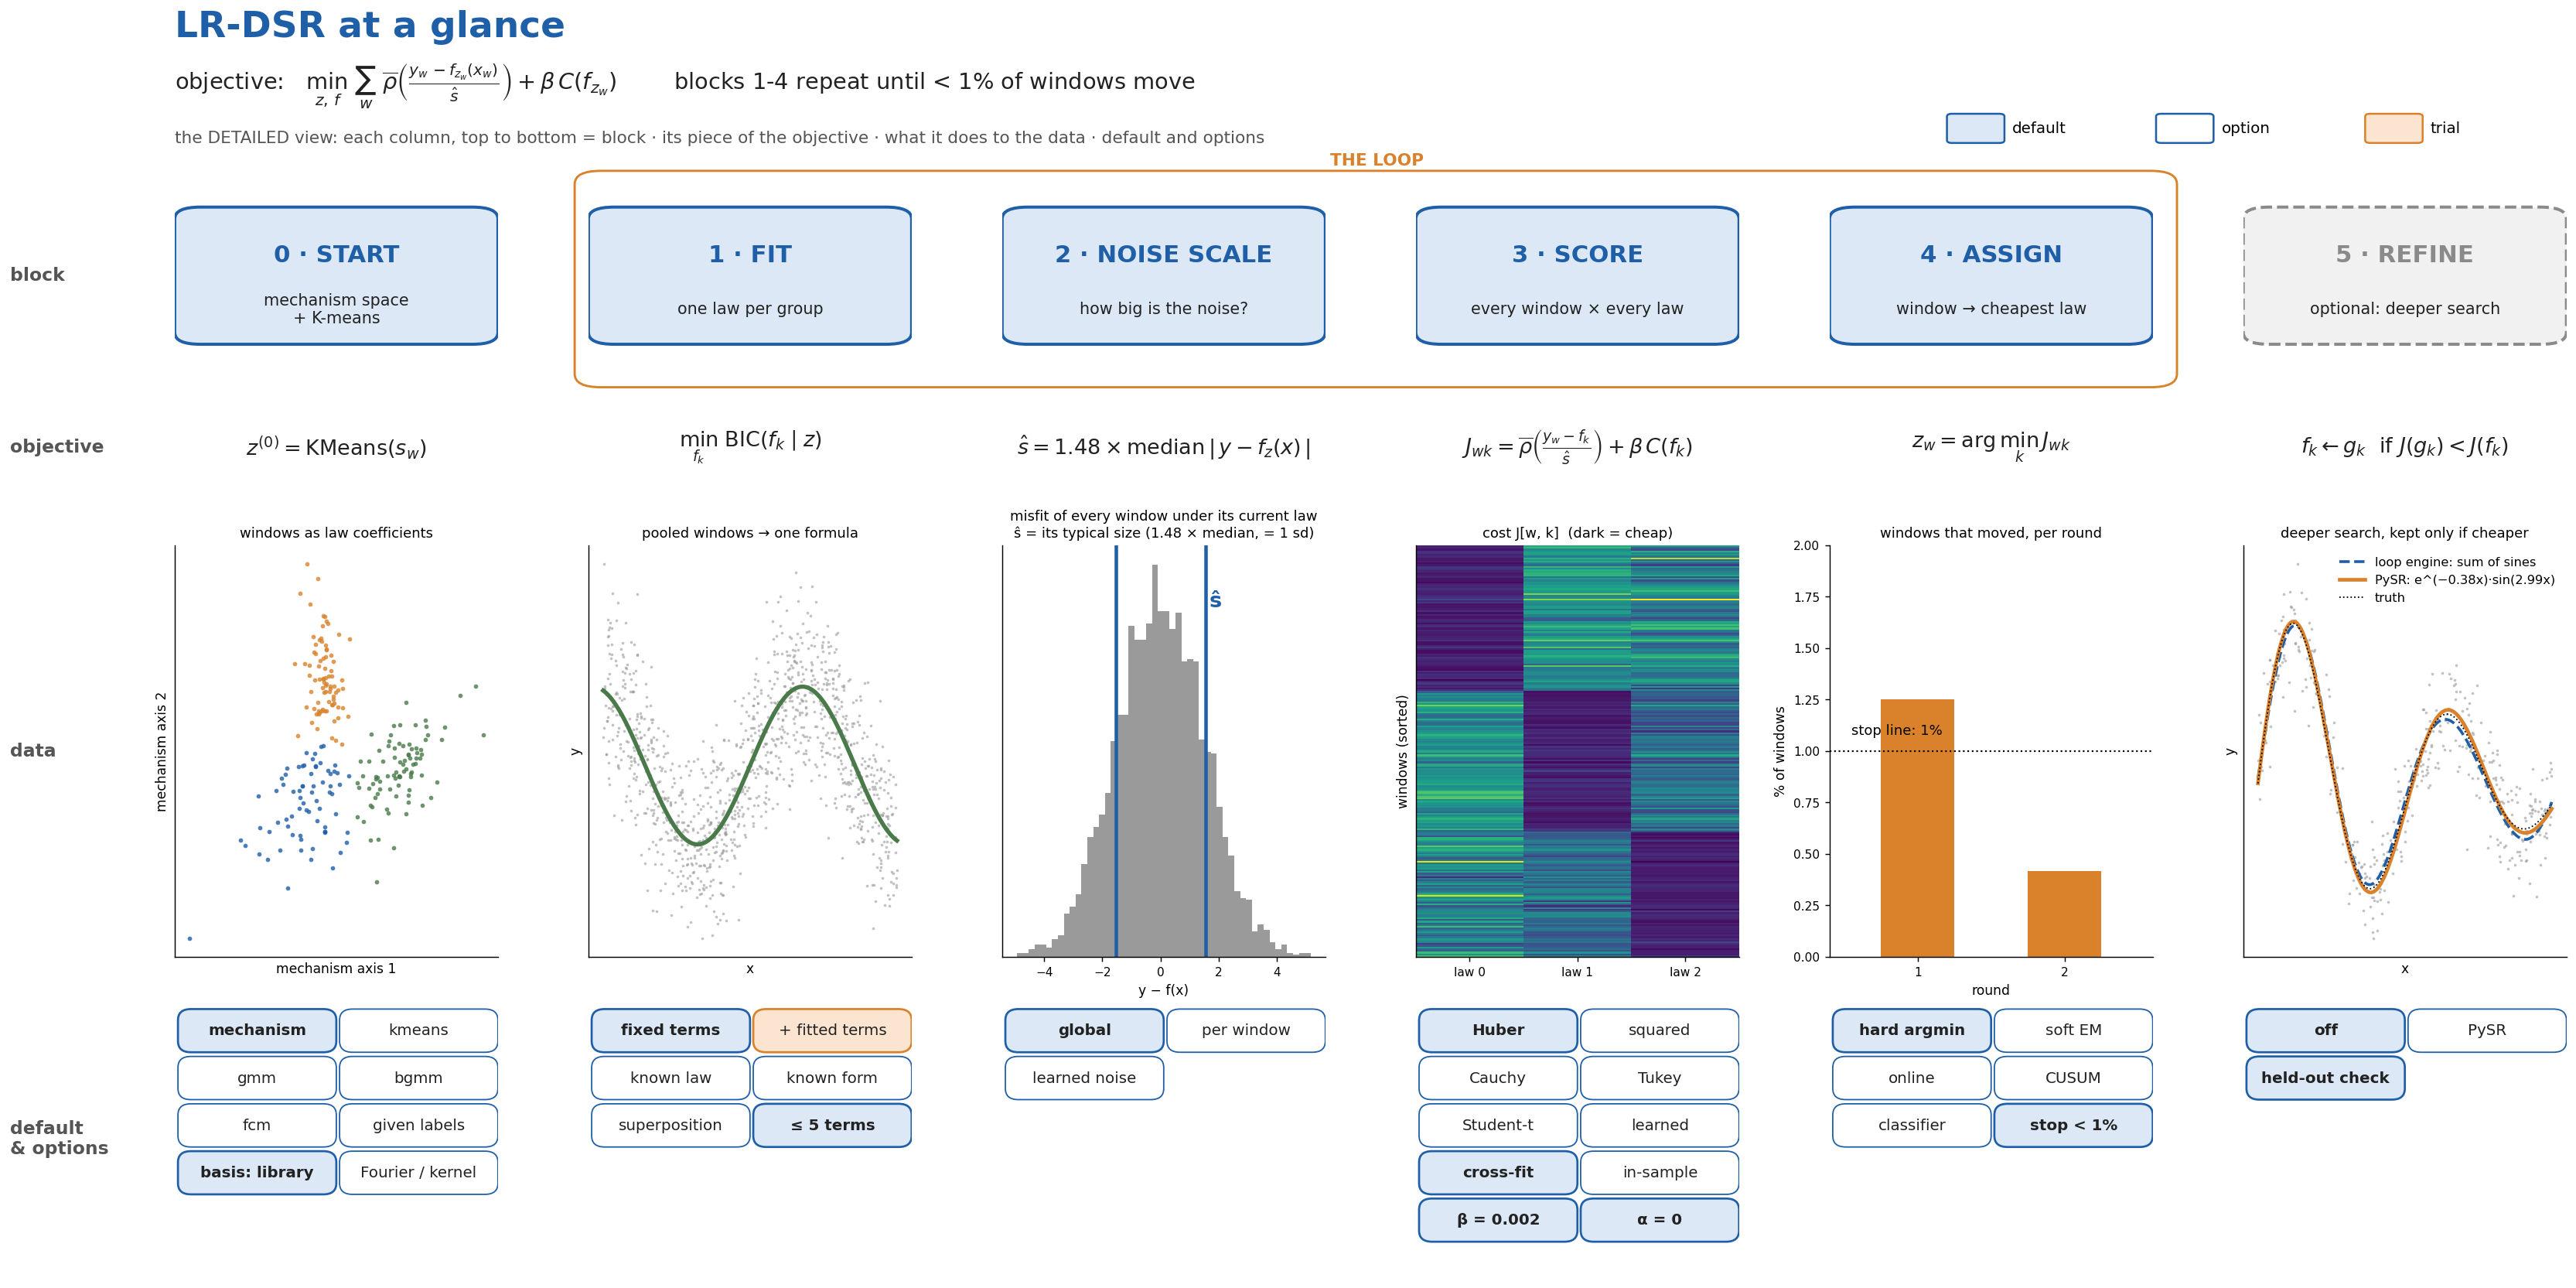

In [5]:
Image(filename=str(DOCS / "00_algorithm_at_a_glance.png"), width=1100)

**The objective** every block serves:

$$
\min_{z,\;f}\;\sum_{w} \underbrace{\frac{1}{n}\sum_i \rho\!\left(\frac{y_{wi}-f_{z_w}(x_{wi})}{\hat s}\right)}_{\text{misfit of window } w \text{ under its law}} \;+\; \beta\, C(f_{z_w})
$$

$z_w$ is the label of window $w$, $f_k$ the law of group $k$, $\rho$ the Huber
loss, $\hat s$ one shared noise scale, $C$ the size of a formula.

## The data

Three laws, 240 windows of 16 noisy samples. The labels `z` are kept aside
**for checking only**; no block ever reads them.

240 windows x 16 samples;  true laws: ['0.8*x^2 + 1.5*x + 0.5', '2.5*sin(2*x) - 0.5', '0.35*x^3 - 1.2']


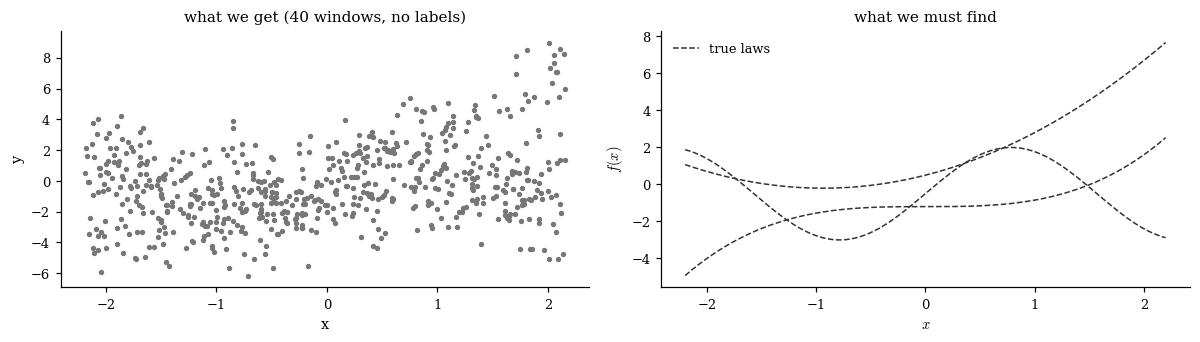

In [6]:
from experiments.functions.data import simulate_function_windows
from lrdsr.core.evaluation import aligned_accuracy

X, y, _, z, equations = simulate_function_windows(
    n_windows=240, window_len=16, noise_std=1.5, geometry_overlap=3.0, seed=11)
W, n, _ = X.shape
K = 3
true_laws = [lambda x: 0.8 * x**2 + 1.5 * x + 0.5, lambda x: 2.5 * np.sin(2 * x) - 0.5,
             lambda x: 0.35 * x**3 - 1.2]
print(f"{W} windows x {n} samples;  true laws: {equations}")
fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].plot(X[:40, :, 0].ravel(), y[:40].ravel(), "o", ms=2.5, color="#777777")
ax[0].set(title="what we get (40 windows, no labels)", xlabel="x", ylabel="y")
viz.plot_laws(truth=true_laws, x_range=(-2.2, 2.2), ax=ax[1]); ax[1].set_title("what we must find")
fig.tight_layout()

---
## Block 0 · START: windows as law coefficients, then K-means

**Role in the objective:** gives the loop its first labels $z^{(0)}$.
**Role on the data:** turns each window into a vector of *law coefficients*,
so windows are compared by the law that made them, not by how they look.

Four steps, straight from `lrdsr/core/mechanism_space.py`:
1. evaluate the term library at every window's inputs: $B_w$;
2. remove the law all windows share: $r_w = y_w - B_w\beta_{\text{pooled}}$;
3. whiten with the pooled Gram matrix, so noise is equal in every direction;
4. project: $s_w = C_w^\top r_w$, one vector per window, then K-means.

In [7]:
from sklearn.cluster import KMeans
from lrdsr.core.mechanism_space import library_basis

B = library_basis(X.reshape(-1, 1), feature_names=["x"]).reshape(W, n, -1)   # 1. terms per window
beta_pooled, *_ = np.linalg.lstsq(B.reshape(W * n, -1), y.reshape(-1), rcond=None)
r = y - B @ beta_pooled                                                        # 2. remove the shared law
G = np.einsum("wnp,wnq->pq", B, B) / W                                         # 3. pooled Gram ...
lam, V = np.linalg.eigh(G)
keep = lam > 1e-6 * lam.max()
M = V[:, keep] / np.sqrt(lam[keep])                                            #    ... and whitening
s = np.einsum("wnp,wn->wp", B @ M, r)                                          # 4. one vector per window
s -= s.mean(0)
z0 = KMeans(K, n_init=30, random_state=11).fit_predict(s)
print(f"mechanism space: {s.shape[1]} coordinates per window;  start accuracy {aligned_accuracy(z, z0):.1%}")

mechanism space: 7 coordinates per window;  start accuracy 98.3%


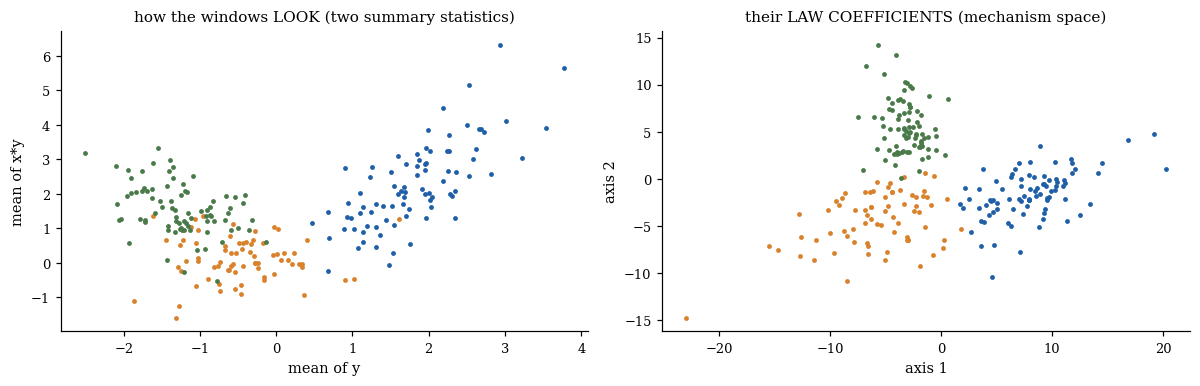

In [8]:
from experiments.common.fitting import window_features
Zf, fnames = window_features(X, y)
P2 = s @ np.linalg.svd(s, full_matrices=False)[2][:2].T
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for k in range(K):
    ax[0].scatter(Zf[z == k, 0], Zf[z == k, 5], s=10, color=viz.regime_color(k), lw=0)
    ax[1].scatter(P2[z == k, 0], P2[z == k, 1], s=10, color=viz.regime_color(k), lw=0)
ax[0].set(title="how the windows LOOK (two summary statistics)", xlabel="mean of y", ylabel="mean of x*y")
ax[1].set(title="their LAW COEFFICIENTS (mechanism space)", xlabel="axis 1", ylabel="axis 2")
fig.tight_layout()

Coloured by the true law (for checking): mixed on the left, separate on the
right. That is why K-means in mechanism space is a good start.

**In the package:** `GroupedDCSR(init="mechanism")` (the default). The other
starts, compared on these windows, before and after the loop:

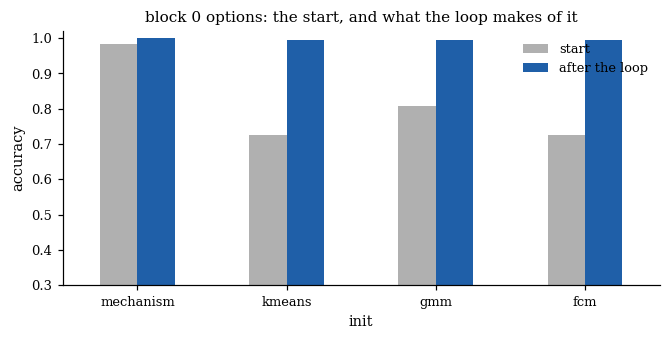

In [9]:
from lrdsr import GroupedDCSR
base = {"n_clusters": K, "alpha_geom": 0.0, "random_state": 11}
rows = []
for init in ("mechanism", "kmeans", "gmm", "fcm"):
    start_only = GroupedDCSR(init=init, max_iter=0, **base).fit(X, y, Zf, feature_names=["x"])
    full = GroupedDCSR(init=init, **base).fit(X, y, Zf, feature_names=["x"])
    rows.append((init, aligned_accuracy(z, start_only.labels), aligned_accuracy(z, full.labels)))
T = pd.DataFrame(rows, columns=["init", "start", "after the loop"]).set_index("init")
ax = T.plot.bar(figsize=(7, 3), rot=0, color=["#b0b0b0", viz.PALETTE[0]])
ax.set(ylim=(0.3, 1.02), ylabel="accuracy", title="block 0 options: the start, and what the loop makes of it");

The look-alike starts (`kmeans`, `gmm`, `fcm` on window summaries) begin much
worse, and here the loop repairs them completely; on harder data it repairs
most, not all (notebook 00, "an honest note on the loop"). The mechanism
start is already right.

*Try it:* set `geometry_overlap=0.5` in the data cell (summaries now carry
information) and rerun: the look-alike starts improve.

---
## Block 1 · FIT: one law per group

**Role in the objective:** with the labels fixed, choose each $f_k$.
**Role on the data:** pool all samples of all windows in a group and find a
short formula: greedy forward selection over the term library, stopping when
BIC stops falling ($\mathrm{BIC} = N\log(\mathrm{RSS}/N) + p\log N$).

group 0  (86 windows):  y = 2.716 +1.487*x -2.2849*cos(x)
group 1  (83 windows):  y = -1.2039 +0.33745*(x)^3
group 2  (71 windows):  y = -0.47148 +2.5942*sin(2*x)


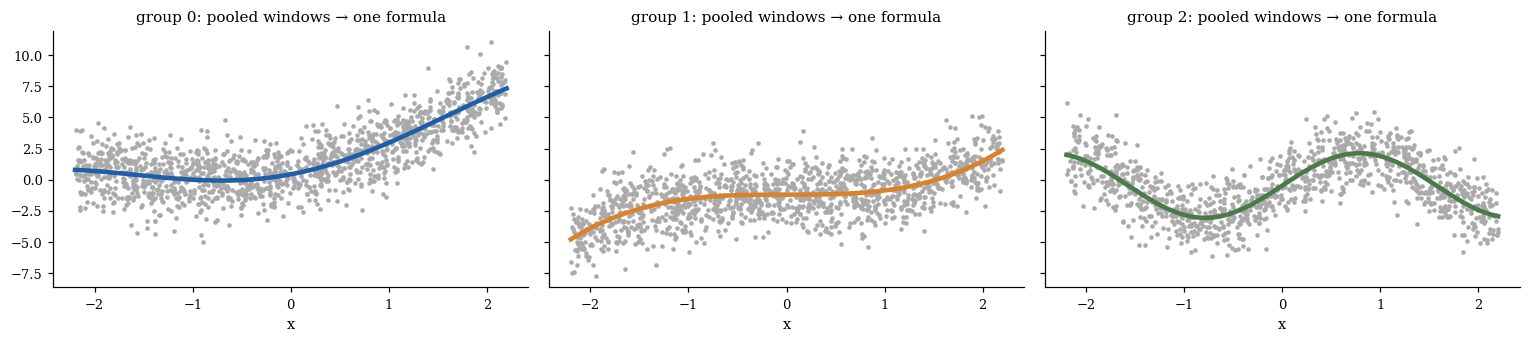

In [10]:
from lrdsr import FastSymbolicRegressor

def fit_laws(labels):
    """Block 1: one law per group, from that group's pooled samples."""
    return [FastSymbolicRegressor(max_terms=5, feature_names=["x"])
            .fit(X[labels == k].reshape(-1, 1), y[labels == k].ravel()) for k in range(K)]

laws = fit_laws(z0)
for k, f in enumerate(laws):
    print(f"group {k}  ({np.sum(z0 == k)} windows):  y = {f.expression()}")
fig, ax = plt.subplots(1, 3, figsize=(14, 3.2), sharey=True)
xg = np.linspace(-2.2, 2.2, 200)
for k, a in enumerate(ax):
    a.plot(X[z0 == k, :, 0].ravel(), y[z0 == k].ravel(), "o", ms=2, color="#aaaaaa")
    a.plot(xg, laws[k].predict(xg[:, None]), color=viz.regime_color(k), lw=3)
    a.set(title=f"group {k}: pooled windows → one formula", xlabel="x")
fig.tight_layout()

**In the package:** `backend="fast"` (the default), `backend_kwargs={"max_terms": 5}`.
Options for this block:

| option | what it changes |
|---|---|
| `backend="fast_sin"` (trial) | adds $\sin(a x)$, $\cos(a x)$ with the frequency $a$ **fitted** |
| `mechanism_specs=[...]` | declare a known law, a known part + searched rest, or a known form with fitted constants, per group |
| `superposition=True` | a group's law may be a mix of two other groups' laws |

The vocabulary matters when a law is outside the library. Two fast
oscillations, $\sin 4x$ vs $\sin 4.6x$:

fast ['0.017293 +0.14691*sin(2*x)', '-0.029723 -0.53765*(x)^3 -0.074136*sin(2*x) +4.4116*x -4.6818*sin(x)']


fast_sin ['0.0049301 +0.97061*sin(4.61*x)', '-0.0116 +1.0099*sin(3.983*x)']


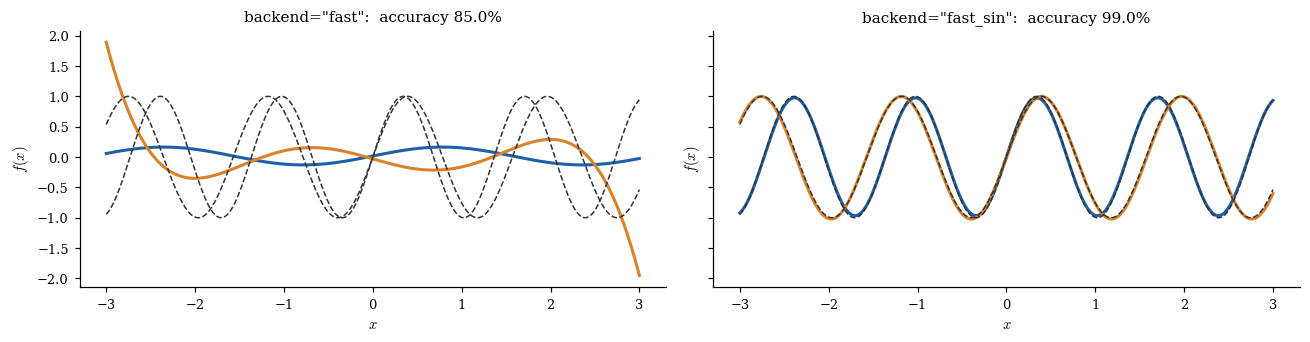

In [11]:
from experiments.problems import zoo
prob = zoo.PROBLEM_BY_NAME["high_frequency"]
Xh, yh, zh = zoo.make_windows(prob, zoo.sigma_for_rho(prob, 0.5), n_windows=200, window_len=32, seed=11)
Zh, _ = window_features(Xh, yh)
fig, ax = plt.subplots(1, 2, figsize=(12, 3.2), sharey=True)
for a, be in zip(ax, ("fast", "fast_sin")):
    r_ = GroupedDCSR(init="mechanism", backend=be, **{**base, "n_clusters": 2}).fit(Xh, yh, Zh, feature_names=["x"])
    viz.plot_laws(r_.models, x_range=prob.x_range, truth=[lambda x: np.sin(4 * x), lambda x: np.sin(4.6 * x)], ax=a)
    a.get_legend().remove()
    a.set_title(f'backend="{be}":  accuracy {aligned_accuracy(zh, r_.labels):.1%}')
    print(be, [m.expression() for m in r_.models])
fig.tight_layout()

---
## Block 2 · NOISE SCALE: how big is the noise?

**Role in the objective:** $\hat s$, the ruler misfits are measured with:
the objective scores $(y - f(x))/\hat s$, a misfit *in units of the noise*.
**Role on the data:** take every window's misfit under its current law,
$y - f_{z}(x)$, and measure its typical size robustly:
$\hat s = 1.48 \times \mathrm{median}\,|y - f_z(x)|$. The median ignores
outliers; the factor 1.48 turns it into a standard deviation (for Gaussian
noise, the median absolute value is 0.674 standard deviations, and
1/0.674 = 1.48). One shared ruler for all windows, so a window a law explains
badly really costs more.

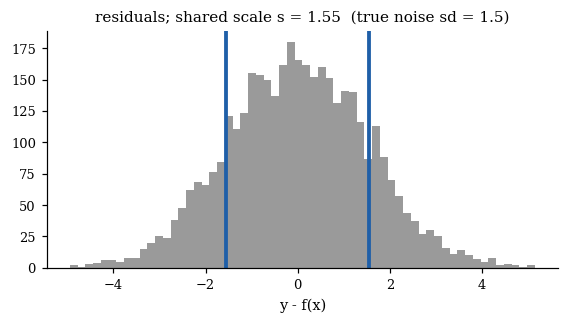

In [12]:
from lrdsr.core.losses import noise_scale

def shared_scale(laws, labels):
    """Block 2: robust spread of every window's residual under its own law."""
    res = np.concatenate([y[w] - laws[labels[w]].predict(X[w]) for w in range(W)])
    return noise_scale(res), res

s_hat, res0 = shared_scale(laws, z0)
plt.figure(figsize=(6, 2.8))
plt.hist(res0, bins=60, color="#9a9a9a")
for sgn in (-1, 1):
    plt.axvline(sgn * s_hat, color=viz.PALETTE[0], lw=2.5)
plt.title(f"residuals; shared scale s = {s_hat:.2f}  (true noise sd = 1.5)"); plt.xlabel("y - f(x)");

**In the package:** `residual_scale="global"` (default) or `"per_window"`
(each window's own spread, which hides the *size* of a misfit). With
`loss="learned"` the noise model and its scale are refitted here.

---
## Block 3 · SCORE: every window under every law

**Role in the objective:** the cost matrix
$J_{wk} = \frac1n\sum_i \rho\big((y_{wi}-f_k(x_{wi}))/\hat s\big)$, what window $w$
would pay to belong to law $k$.
**Role on the data:** one detail matters: a law fitted *on* a window flatters
it. So a window's cost under its **own** group's law is computed with a law
fitted **without** it (3-fold cross-fitting), as `score_mode="cross_fit"` does.

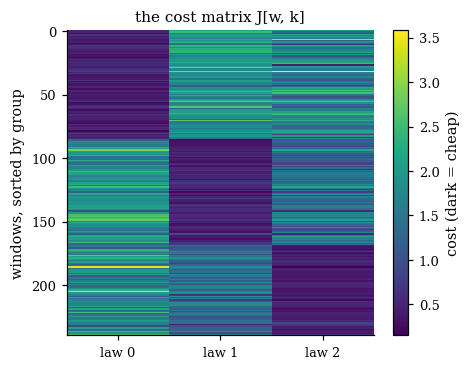

In [13]:
from lrdsr.core.losses import aggregate_window_residual

def cost_matrix(laws, labels, s_hat, folds=3, seed=11):
    """Block 3: Huber cost of every window under every law; own group out-of-fold."""
    J = np.array([[aggregate_window_residual(y[w], f.predict(X[w]), scale=s_hat) for f in laws]
                  for w in range(W)])
    rng = np.random.default_rng(seed)
    for k in range(K):
        members = np.flatnonzero(labels == k)
        for fold in np.array_split(rng.permutation(members), folds):
            rest = np.setdiff1d(members, fold)
            f = FastSymbolicRegressor(max_terms=5).fit(X[rest].reshape(-1, 1), y[rest].ravel())
            for w in fold:
                J[w, k] = aggregate_window_residual(y[w], f.predict(X[w]), scale=s_hat)
    return J

J = cost_matrix(laws, z0, s_hat)
order = np.argsort(z0, kind="stable")
plt.figure(figsize=(4.5, 3.6))
plt.imshow(J[order], aspect="auto", cmap="viridis", interpolation="nearest")
plt.colorbar(label="cost (dark = cheap)")
plt.xticks(range(K), [f"law {k}" for k in range(K)]); plt.ylabel("windows, sorted by group")
plt.title("the cost matrix J[w, k]");

**In the package:** `loss="huber"` (default, δ = 1.345 noise sd), or
`"squared"`, `"absolute"`, `"cauchy"`, `"tukey"`, `"student_t"`, `"learned"`;
`score_mode="cross_fit"` (default) or `"in_sample"`; plus a complexity weight
`beta_complexity` and an optional geometry weight `alpha_geom` (0 by default).

The loss matters when the noise has outliers. The same windows with
heavy-tailed noise (Student-t, 2 degrees of freedom):

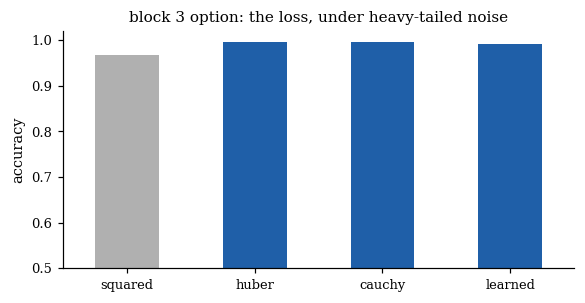

In [14]:
rng = np.random.default_rng(0)
clean = np.stack([true_laws[k](X[w, :, 0]) for w, k in enumerate(z)])
y_heavy = clean + rng.standard_t(2.0, size=y.shape)
acc = {loss: aligned_accuracy(z, GroupedDCSR(init="mechanism", loss=loss, **base)
                              .fit(X, y_heavy, Zf, feature_names=["x"]).labels)
       for loss in ("squared", "huber", "cauchy", "learned")}
ax = pd.Series(acc).plot.bar(figsize=(6, 2.8), rot=0, color=["#b0b0b0"] + [viz.PALETTE[0]] * 3)
ax.set(ylim=(0.5, 1.02), ylabel="accuracy", title="block 3 option: the loss, under heavy-tailed noise");

---
## Block 4 · ASSIGN, and the loop

**Role in the objective:** with the laws fixed, $z_w = \arg\min_k J_{wk}$:
every window moves to its cheapest law. Then blocks 1-4 repeat until fewer
than 1% of windows move. That is the whole algorithm: here it is in full,
built from the four functions above.

In [15]:
def lrdsr_by_hand(z_start, max_rounds=10, tol=0.01):
    labels, history = z_start.copy(), []
    for rnd in range(max_rounds):
        laws = fit_laws(labels)                      # block 1
        s_hat, _ = shared_scale(laws, labels)        # block 2
        J = cost_matrix(laws, labels, s_hat)         # block 3
        new = J.argmin(axis=1)                       # block 4
        moved = np.mean(new != labels)
        history.append((rnd + 1, moved, aligned_accuracy(z, new)))
        labels = new
        if moved < tol:
            break
    return labels, fit_laws(labels), pd.DataFrame(history, columns=["round", "moved", "accuracy"])

# start from a BAD partition on purpose, to watch the loop work
bad = KMeans(K, n_init=10, random_state=0).fit_predict((Zf - Zf.mean(0)) / Zf.std(0))
lab_hand, laws_hand, hist = lrdsr_by_hand(bad)
hist

,round,moved,accuracy
0,1,0.2792,0.9917
1,2,0.0083,1.0000


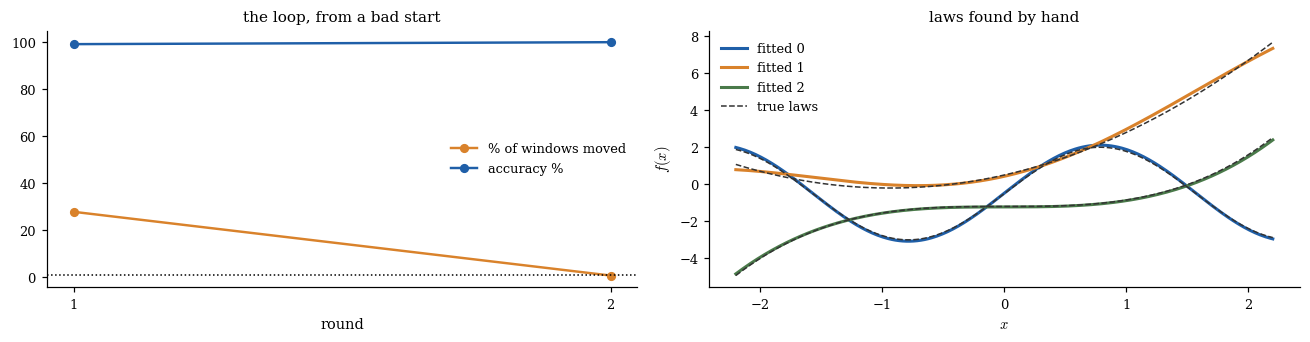

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.2))
ax[0].plot(hist["round"], 100 * hist.moved, "-o", color=viz.PALETTE[1], label="% of windows moved")
ax[0].plot(hist["round"], 100 * hist.accuracy, "-o", color=viz.PALETTE[0], label="accuracy %")
ax[0].axhline(1, color="k", ls=":", lw=1)
ax[0].set(xlabel="round", title="the loop, from a bad start", xticks=hist["round"])
ax[0].legend()
viz.plot_laws(laws_hand, x_range=(-2.2, 2.2), truth=true_laws, ax=ax[1]); ax[1].set_title("laws found by hand")
fig.tight_layout()

**The same thing, in the package**, from the same bad start and from the
default mechanism-space start:

In [17]:
pkg_bad = GroupedDCSR(init=bad, **base).fit(X, y, Zf, feature_names=["x"])
pkg = GroupedDCSR(init="mechanism", **base).fit(X, y, Zf, feature_names=["x"])
print(f"by hand, bad start:        {aligned_accuracy(z, lab_hand):.1%}")
print(f"package, bad start:        {aligned_accuracy(z, pkg_bad.labels):.1%}")
print(f"package, mechanism start:  {aligned_accuracy(z, pkg.labels):.1%}")
print("\nthe package's laws:")
for m in pkg.models:
    print("   y =", m.expression())

by hand, bad start:        100.0%
package, bad start:        100.0%
package, mechanism start:  100.0%

the package's laws:
   y = 2.7175 +1.4884*x -2.2863*cos(x)
   y = -1.2222 +0.33956*(x)^3
   y = -0.48016 +2.5939*sin(2*x)


The package does the same four steps and adds two safeguards the hand version
skips: tiny groups are repaired, and each cost term is divided by its median
before weighting, so `alpha_geom` and `beta_complexity` are real trade-offs.

**Other ways to assign** (same idea, different machinery):

| estimator | assignment |
|---|---|
| `SoftLRDSR` | a *probability* per law for every window (EM) |
| `OnlineLRDSR` | one window at a time, in real time; can create new laws |
| `CusumSegmenter` | sample by sample, detects switches in one stream |
| `LawClassifier` | labels known: laws per class, new windows to the best class |

The soft version on our windows: each row is a window, and the colours are
its probabilities.

soft EM accuracy 100.0%;  1.2% of windows less than 90% sure


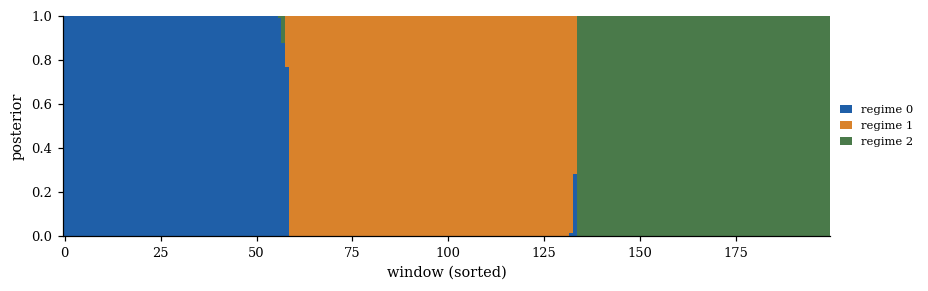

In [18]:
from lrdsr import SoftLRDSR
soft = SoftLRDSR(n_clusters=K, feature_names=["x"], random_state=11).fit(X, y)
print(f"soft EM accuracy {aligned_accuracy(z, soft.labels):.1%};  "
      f"{np.mean(soft.responsibilities.max(1) < 0.9):.1%} of windows less than 90% sure")
fig, ax = plt.subplots(figsize=(9, 2.6))
viz.plot_responsibilities(soft.responsibilities, ax=ax);

---
## Block 5 · REFINE (optional): a deeper law search, once per group

**Role in the objective:** one more "fit laws, labels fixed" step, with a far
larger vocabulary. **Role on the data:** PySR builds formulas from operators
and fits the constants inside them. Too slow for the loop, so it runs once
per final group, and its law **replaces the loop's only if it is cheaper on
held-out windows**, judged on the same cost.

It needs `pip install "pysr<2"` (Julia installs on first use). The cell
below skips itself when PySR is missing.

In [19]:
import importlib.util
if importlib.util.find_spec("pysr") is None:
    print('PySR not installed: pip install "pysr<2" to run block 5.')
else:
    from lrdsr.core.refine import refine_laws
    from experiments.openlaws.run import PROBLEMS as OPEN
    dp = OPEN[1]                                                  # damped: exp(-0.4x) sin 3x vs exp(-0.1x) sin 3x
    Xd, yd, zd = zoo.make_windows(dp, zoo.sigma_for_rho(dp, 1.0), n_windows=150, window_len=48, seed=23)
    Zd, _ = window_features(Xd, yd)
    loop = GroupedDCSR(init="mechanism", backend="fast_sin", **{**base, "n_clusters": 2}).fit(
        Xd, yd, Zd, feature_names=["x"])
    out = refine_laws(loop, Xd, yd, seed=23)
    for k in range(2):
        print(f"group {k}:  loop law   {loop.models[k].expression()}")
        print(f"          PySR found {out.expressions_found[k]}")
        print(f"          held-out cost  loop {out.cost_before[k]:.4f}   PySR {out.cost_found[k]:.4f}"
              f"   -> {'REPLACED' if out.replaced[k] else 'kept the loop law'}")
    print(f"\naccuracy: loop {aligned_accuracy(zd, loop.labels):.1%} -> after block 5 {aligned_accuracy(zd, out.labels):.1%}")

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


group 0:  loop law   0.01046 +0.84019*sin(3.004*x) +0.051988*sin(3.943*x) +0.061538*sin(2*x)
          PySR found exp(x0*(-0.091159195))*sin(x0/0.3336315)
          held-out cost  loop 0.4662   PySR 0.4635   -> REPLACED
group 1:  loop law   0.037662 +0.54427*sin(3.027*x) +0.057673*cos(1.571*x) +0.11836*sin(4.004*x) +0.10179*sin(2*x)
          PySR found sin(x0/0.33396938)/(x0 + 0.65740025)
          held-out cost  loop 0.4543   PySR 0.4690   -> kept the loop law

accuracy: loop 100.0% -> after block 5 100.0%


---
## The whole thing in three lines

```python
from lrdsr import GroupedDCSR
res = GroupedDCSR(n_clusters=K, alpha_geom=0.0).fit(X_seq, y_seq, Z, feature_names=["x"])
res.labels, [m.expression() for m in res.models]
```

`X_seq` is `(windows, samples, inputs)`, `y_seq` is `(windows, samples)`,
`Z` any window-level features (unused when `alpha_geom=0`; zeros are fine).

| block | parameter | default | options |
|---|---|---|---|
| 0 start | `init` | `"mechanism"` | `"kmeans"`, `"gmm"`, `"bgmm"`, `"fcm"`, an array |
| 1 fit | `backend`, `backend_kwargs` | `"fast"`, 5 terms | `"fast_sin"` (trial), `mechanism_specs`, `superposition` |
| 2 noise | `residual_scale` | `"global"` | `"per_window"` |
| 3 score | `loss`, `score_mode` | `"huber"`, `"cross_fit"` | 5 other losses, `"learned"`; `"in_sample"` |
| 3 score | `beta_complexity`, `alpha_geom` | 0.002 (project setting), 0 | any weight |
| 4 assign | the estimator | `GroupedDCSR` | `SoftLRDSR`, `OnlineLRDSR`, `CusumSegmenter`, `LawClassifier` |
| 4 stop | `max_iter`, `tol` | 10, 0.01 | |
| 5 refine | `refine_laws(res, X, y)` | off | PySR (or any engine) |

**Try it:** change the noise (`noise_std`), the window length (`window_len`)
or the number of laws, and watch which block starts to struggle. Notebook
`00_summary` shows how the whole method compares with the alternatives.